In [7]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
import torch
from pretrain import LLM, Config

In [8]:
t = AutoTokenizer.from_pretrained('/root/autodl-tmp/train_qwen3_next_from_scratch/result_pretrain/checkpoint-5000')
AutoConfig.register("moe_model", Config)
AutoModelForCausalLM.register(Config, LLM)

In [9]:
model = AutoModelForCausalLM.from_pretrained('/root/autodl-tmp/train_qwen3_next_from_scratch/result_pretrain/checkpoint-5000')

In [10]:
input_data = [t.bos_token_id] + t.encode('你是一个')
print(input_data)

[2, 224, 609, 1590]


In [11]:
for token in model.generate({"input_ids":torch.tensor(input_data).unsqueeze(0), "labels":None}, t.eos_token_id, 100, stream=False,temperature=0.0, top_k=1, repetition_penalty=1):
    print(t.decode(token[0]))

非常有经验的团队，你会发现，你会发现，你会发现，你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会发现你会


In [12]:
model = AutoModelForCausalLM.from_pretrained('/root/autodl-tmp/train_qwen3_next_from_scratch/result_sft/checkpoint-5000')

In [13]:
input_data = t.apply_chat_template([{'role':'user', 'content':'什么是人工智能？'}], add_generation_prompt=True)
print(input_data)

[2, 2766, 202, 1542, 346, 2836, 815, 3, 2252, 2, 1862, 502, 202]


In [14]:
for token in model.generate({"input_ids":torch.tensor(input_data).unsqueeze(0), "labels":None}, t.eos_token_id, 500, stream=False,temperature=0.0, top_k=1, repetition_penalty=1):
    print(t.decode(token[0]))

 人工智能（Artificial Intelligence，简称AI）是指通过计算机程序模拟人类智能的技术。人工智能技术在许多领域都有广泛的应用，包括医疗保健、金融、交通、制造业、交通运输、金融服务、交通运输、医疗保健、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通运输、交通


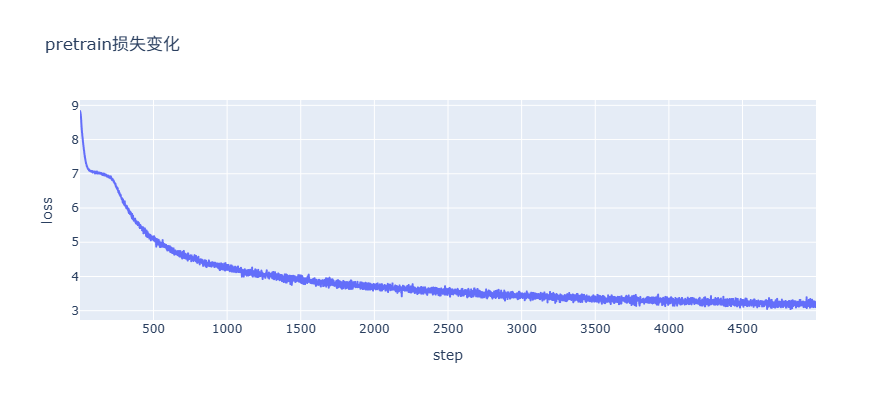

In [15]:
import json
import pandas as pd
with open('/root/autodl-tmp/train_qwen3_next_from_scratch/result_pretrain/checkpoint-5000/trainer_state.json' , 'r', encoding='utf-8') as f:
    data = json.load(f)
    log_history = data['log_history']
    steps = []
    losses = []
    for i in log_history[:-1]:
        step = i['step']
        loss = i['loss']
        steps.append(step)
        losses.append(loss)

import seaborn as sns
import plotly.express as px

# 创建一个DataFrame
df = pd.DataFrame({
    'Step': steps,
    'Loss': losses
})

# 使用Plotly绘制散点图
fig = px.line(df, x='Step', y='Loss', title='pretrain损失变化',
                 labels={'Step': 'step', 'Loss': 'loss'},
                 )  # 添加趋势线可选

fig.update_layout(width=600, height=400)
# 显示图表
fig.show()

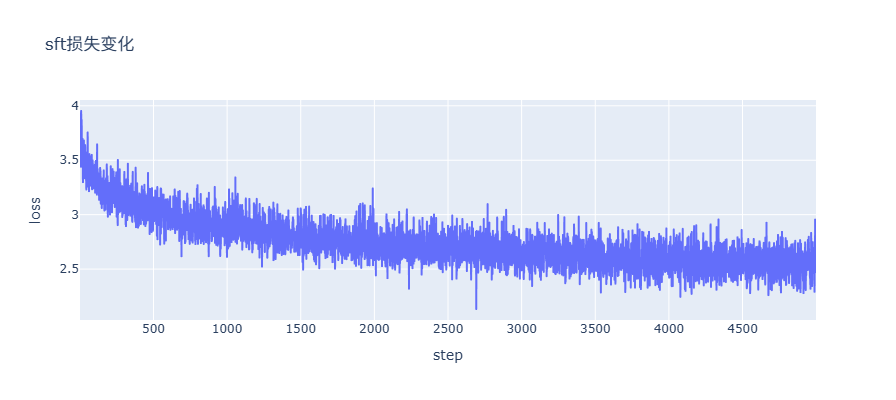

In [16]:
import json
import pandas as pd
with open('/root/autodl-tmp/train_qwen3_next_from_scratch/result_sft/checkpoint-5000/trainer_state.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
    log_history = data['log_history']
    steps = []
    losses = []
    for i in log_history[:-1]:
        step = i['step']
        loss = i['loss']
        steps.append(step)
        losses.append(loss)

import seaborn as sns
import plotly.express as px

# 创建一个DataFrame
df = pd.DataFrame({
    'Step': steps,
    'Loss': losses
})

# 使用Plotly绘制散点图
fig = px.line(df, x='Step', y='Loss', title='sft损失变化',
                 labels={'Step': 'step', 'Loss': 'loss'},
                 )  # 添加趋势线可选

fig.update_layout(width=600, height=400)
# 显示图表
fig.show()